In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/bank-customer-churn-prediction-dataset/Churn_Modelling.csv


In [2]:
df=pd.read_csv('/kaggle/input/bank-customer-churn-prediction-dataset/Churn_Modelling.csv')

# load the libraries

In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


In [4]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


we can see there are several categorical columns like surname,geography,gender

In [6]:
df.shape

(10000, 14)

In [7]:
df.columns

Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography',
       'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='object')

In [8]:
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


drop the rows which cant be helpful in this task like surname,rownumber and customer id..dropping ID like columns avoids data leakage and noise

In [9]:
df.drop(columns=['RowNumber', 'CustomerId', 'Surname'], inplace=True)


now we will do target variable anaylsis

In [10]:
df['Exited'].value_counts()


Exited
0    7963
1    2037
Name: count, dtype: int64

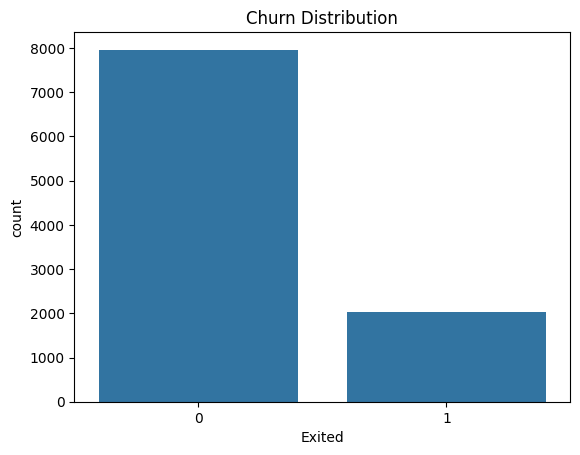

In [11]:
sns.countplot(x='Exited', data=df)
plt.title("Churn Distribution")
plt.show()


we can clearly see the datset is imbalanced atleast 80 percent of data is negative means customer stayed and 20 percent churned...

# BIVARIATE EDA
churn vs geography

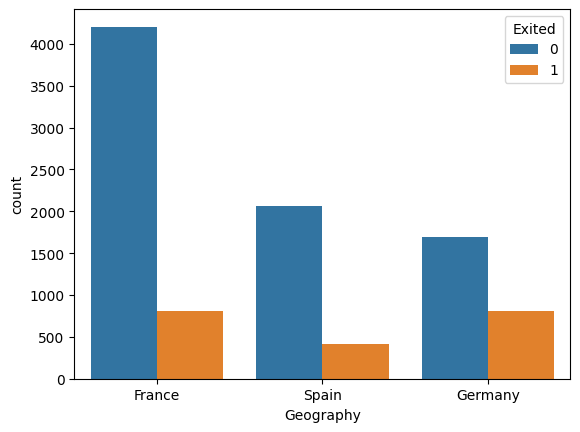

In [12]:
sns.countplot(x='Geography', hue='Exited', data=df)
plt.show()


some countries churn more like france ..it may helps in prediction task

churn vs gender

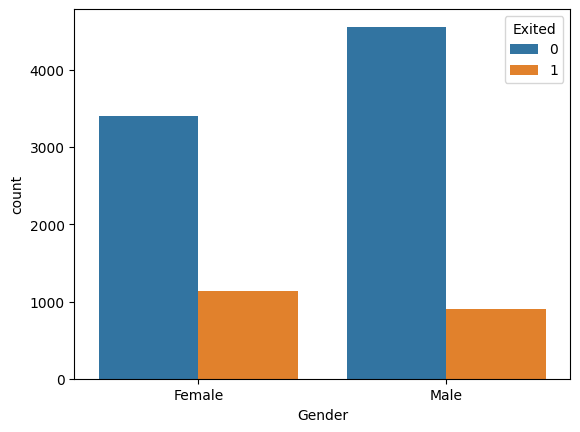

In [13]:
sns.countplot(x='Gender', hue='Exited', data=df)
plt.show()


churn vs age

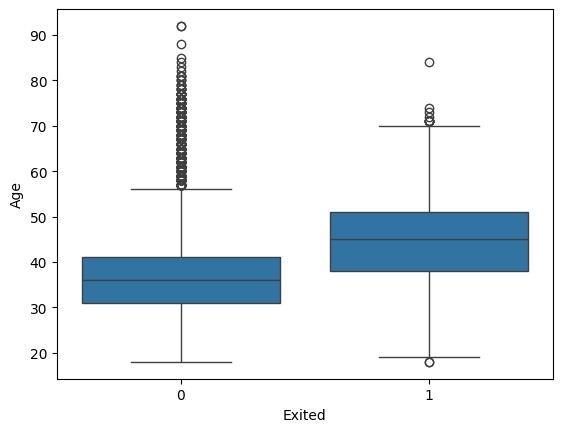

In [14]:
sns.boxplot(x='Exited', y='Age', data=df)
plt.show()


we can seee older customer tend to churn more 

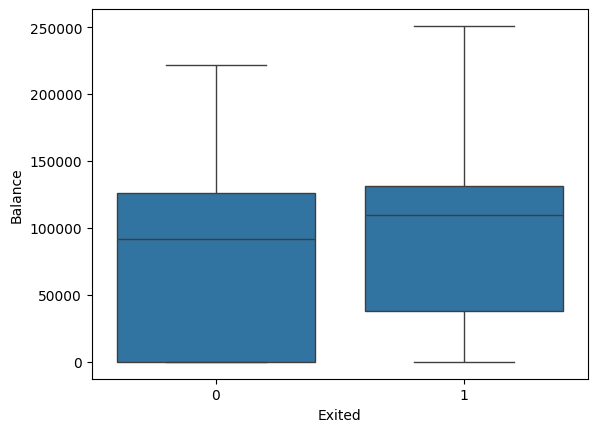

In [15]:
sns.boxplot(x='Exited', y='Balance', data=df)
plt.show()


# feature engineering

In [16]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap='coolwarm', annot=False)
plt.show()


ValueError: could not convert string to float: 'France'

<Figure size 1200x800 with 0 Axes>

In [ ]:
df.columns

In [ ]:
X = df.drop('Exited', axis=1)
y = df['Exited']


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


we will do fetaure scaling as algorithms like logistic regresion ,svm and knn requires feature scaling

In [ ]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


# baseline model-logistic regression

In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)


In [ ]:
y_pred = model.predict(X_test)


In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred))


In [ ]:
print(classification_report(y_test, y_pred))


we can see that recall and precision scores are poor due to imbalance class

In [ ]:
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d')
plt.show()


In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    random_state=42
)

rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)


In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred))


some improvement in recall but nor great

In [ ]:
feature_importance = pd.Series(
    rf.feature_importances_,
    index=df.drop('Exited', axis=1).columns
).sort_values(ascending=False)

feature_importance.head(10)


In [ ]:
feature_importance.plot(kind='bar', figsize=(10,4))
plt.show()


now we will try different approach apply some techniques to reduce the class imbalace.. first method id to use class imbalance parameter in logistic regression

In [ ]:
lr_bal = LogisticRegression(
    max_iter=1000,
    class_weight='balanced'
)

lr_bal.fit(X_train, y_train)
y_pred_bal = lr_bal.predict(X_test)

print(classification_report(y_test, y_pred_bal))


In [ ]:
rf_bal = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,
    class_weight='balanced',
    random_state=42
)

rf_bal.fit(X_train, y_train)
rf_pred_bal = rf_bal.predict(X_test)

print(classification_report(y_test, rf_pred_bal))


Older customers with multiple products but low activity and high balance, especially in Germany, are more likely to churn.  Because churn data is imbalanced, accuracy was misleading. I optimized the model for recall by using class-weighted learning and lowering the decision threshold. This significantly improved churn detection, which aligns better with business objectives where missing a churner is costlier than a false alarm

RF gives:
High recall
Much better precision
Better overall balance
Is This “Good Enough” for Real Use?YES.In many real churn systems.Recall of 65–75% is considered strong..Precision of 50–60% is acceptable..But we can still push recall further if required.

Adjust Threshold..Right now, you’re still using threshold = 0.5.Let’s lower it.

In [ ]:
lr_bal = LogisticRegression(
    max_iter=1000,
    class_weight='balanced'
)

lr_bal.fit(X_train, y_train)
y_prob = rf_bal.predict_proba(X_test)[:, 1]

y_pred_30 = (y_prob >= 0.30).astype(int)
print(classification_report(y_test, y_pred_30))



In [ ]:
rf_bal = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,
    class_weight='balanced',
    random_state=42
)

rf_bal.fit(X_train, y_train)
y_prob = rf_bal.predict_proba(X_test)[:, 1]

y_pred_30 = (y_prob >= 0.30).astype(int)
print(classification_report(y_test, y_pred_30))



In [ ]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

plt.plot(thresholds, recall[:-1], label='Recall')
plt.plot(thresholds, precision[:-1], label='Precision')
plt.xlabel("Threshold")
plt.legend()
plt.show()


initially, accuracy was high but churn recall was low due to class imbalance. I addressed this using class-weighted learning and optimized for recall. This improved churn recall from ~40% to over 70%, which aligns better with business goals where missing a churner is more costly than a false alarm